# 🔍 01 · 边缘检测与特征提取

> 目标：边缘是传统 CV 的「第一性特征」。手写 Sobel 梯度 → 非极大值抑制 → Canny 五步 → Harris 角点 → HOG 特征，
> 建立「怎么把一张图变成一串可匹配/可分类的向量」的完整链路。

> 🧩 **生活化类比**：边缘 = 素描画里的轮廓线。人眼靠轮廓认物（物体边界、明暗交界），
> 机器也一样——先找边，再根据边的形状/方向描述物体。


## 1. 为什么边缘重要

- 边缘 = **灰度剧烈变化**处 = 物体边界 / 光照突变 / 纹理细节
- 边缘检测 = **求梯度**：$\\nabla f = (\\partial f/\\partial x,\\, \\partial f/\\partial y)$
- 梯度幅值 $|\\nabla f|=\\sqrt{G_x^2+G_y^2}$ 大 → 是边；方向 $\\theta=\\arctan2(G_y,G_x)$ → 边的朝向
- 从边 → 角点（边方向也剧烈变化）→ 区域 → 物体，是传统 CV 由局部到全局的管线

**核心公式（一阶差分近似）**：$G_x = f[i{+}1,j] - f[i{-}1,j]$（对中心像素的对称差分，抗噪声略好于 $f[i{+}1]{-}f[i]$）


## 2. Sobel / Prewitt：带权重的差分核

| 算子 | $G_x$ 核 | $G_y$ 核 | 特点 |
|------|----------|----------|------|
| Prewitt | `[-1 0 1; -1 0 1; -1 0 1]` | `[-1 -1 -1; 0 0 0; 1 1 1]` | 一阶差分，对噪声敏感 |
| **Sobel** | `[-1 0 1; -2 0 2; -1 0 1]` | `[-1 -2 -1; 0 0 0; 1 2 1]` | 中心行权重 2 → 更抗噪、边缘定位更好 |
| Scharr | `[-3 0 3; -10 0 10; -3 0 3]` | 转置 | 旋转对称性更好，OpenCV 推荐小核用 |

> Sobel 的 `-2 0 2` 本质是「中心差分 + 局部平滑（[1,2,1] 平滑 + 差分）」，即**先平滑后差分**的廉价实现。


梯度幅值范围: [0.000, 2.094]


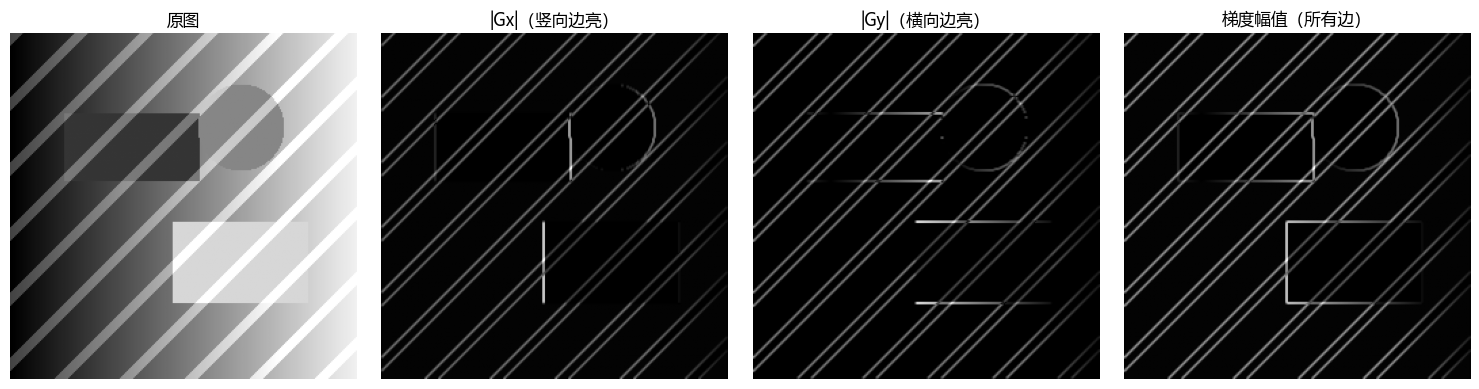

结论：|Gx| 只响应竖直方向变化（横边），|Gy| 只响应水平方向变化（竖边）


In [1]:
# ---------- 实验 1：手写 Sobel 梯度（复用 00 篇 conv2d） ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(42)

def conv2d(x, k, mode='edge'):
    H, W = x.shape
    kh, kw = k.shape
    ph, pw = kh // 2, kw // 2
    xp = np.pad(x, ((ph, ph), (pw, pw)), mode=mode)
    cols = np.lib.stride_tricks.sliding_window_view(xp, (kh, kw))
    return np.einsum('ijkl,kl->ij', cols, k)

# 复刻 00 篇合成图（不同光照下的多个几何体）
def make_test_image(size=256):
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32)
    img = (xx / size) * 0.9 + 0.05
    img[60:110, 40:140] = 0.25
    img[140:200, 120:220] = 0.85
    mask = (xx - 170) ** 2 + (yy - 70) ** 2 < 32 ** 2
    img[mask] = 0.55
    stripe = (xx + yy) % 48 < 10
    img[stripe] = np.clip(img[stripe] + 0.25, 0, 1)
    return np.clip(img, 0, 1)

img = make_test_image()
SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
SOBEL_Y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

def sobel_grad(g):
    Gx = conv2d(g, SOBEL_X)
    Gy = conv2d(g, SOBEL_Y)
    mag = np.hypot(Gx, Gy)
    ang = np.degrees(np.arctan2(Gy, Gx)) % 180      # 方向折叠到 [0,180)
    return Gx, Gy, mag, ang

Gx, Gy, mag, ang = sobel_grad(img)
print('梯度幅值范围: [%.3f, %.3f]' % (mag.min(), mag.max()))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(np.abs(Gx), cmap='gray'); axes[1].set_title('|Gx|（竖向边亮）'); axes[1].axis('off')
axes[2].imshow(np.abs(Gy), cmap='gray'); axes[2].set_title('|Gy|（横向边亮）'); axes[2].axis('off')
axes[3].imshow(mag, cmap='gray'); axes[3].set_title('梯度幅值（所有边）'); axes[3].axis('off')
plt.tight_layout(); plt.savefig('images/cv01_sobel.png', dpi=110, bbox_inches='tight'); plt.show()
print('结论：|Gx| 只响应竖直方向变化（横边），|Gy| 只响应水平方向变化（竖边）')


## 3. 梯度方向分箱与非极大值抑制（NMS）

梯度幅值图是「宽边带」，要变成**单像素细线**需 NMS：只保留沿梯度方向上的局部极大。

- 梯度方向量化 4 个方向：0°（水平）、45°、90°（垂直）、135°
- 对每个像素，比较它与**梯度方向前后两个邻居**的幅值，不是最大就压成 0

> 🧩 **类比**：山脊线提取——沿着山坡走向走，只有「最高点」才画线，两侧矮的都擦掉，得到一条细脊线。


NMS 后非零像素占比: 45.8%（原来 18.6%）


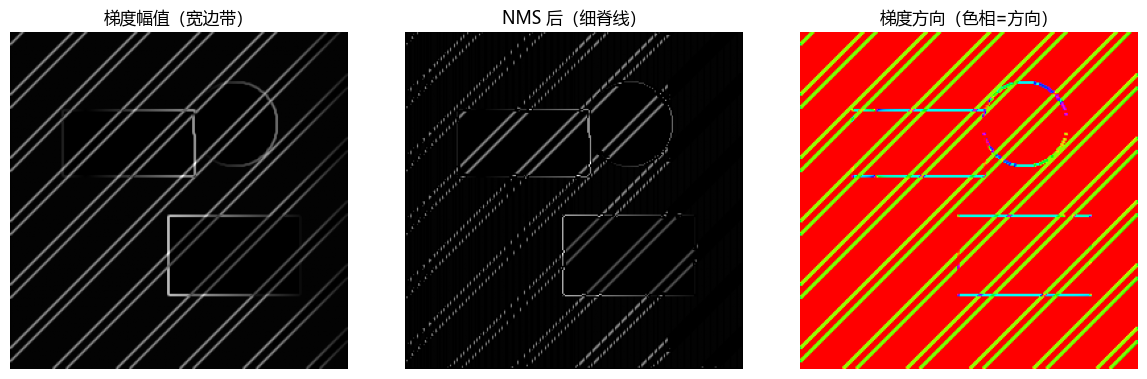

In [2]:
# ---------- 实验 2：梯度方向分箱 + NMS 手写 ----------
def nms(mag, ang):
    H, W = mag.shape
    out = np.zeros_like(mag)
    ang_q = (np.round(ang / 45) % 4).astype(int)     # 0:水平 1:45° 2:垂直 3:135°
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            a = ang_q[i, j]
            if a == 0:
                n1, n2 = mag[i, j - 1], mag[i, j + 1]
            elif a == 1:
                n1, n2 = mag[i - 1, j + 1], mag[i + 1, j - 1]
            elif a == 2:
                n1, n2 = mag[i - 1, j], mag[i + 1, j]
            else:
                n1, n2 = mag[i - 1, j - 1], mag[i + 1, j + 1]
            out[i, j] = mag[i, j] if mag[i, j] >= max(n1, n2) else 0.0
    return out

n = nms(mag, ang)
print('NMS 后非零像素占比: %.1f%%（原来 %.1f%%）' %
      (100 * (n > 0).mean(), 100 * (mag > 0.05).mean()))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(mag, cmap='gray'); axes[0].set_title('梯度幅值（宽边带）'); axes[0].axis('off')
axes[1].imshow(n, cmap='gray'); axes[1].set_title('NMS 后（细脊线）'); axes[1].axis('off')
axes[2].imshow(ang, cmap='hsv', vmin=0, vmax=180); axes[2].set_title('梯度方向（色相=方向）'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv01_nms.png', dpi=110, bbox_inches='tight'); plt.show()


## 4. Canny：五步完整流程（面试手推主菜）

| 步骤 | 操作 | 解决什么 |
|------|------|----------|
| 1 | 高斯平滑（$\\sigma$ 小则细节多噪声多） | 去噪 |
| 2 | Sobel 求梯度幅值/方向 | 找边响应 |
| 3 | 非极大值抑制（沿梯度方向） | 细线化 |
| 4 | 双阈值 $T_{low}<T_{high}$ 分类：强边 / 弱边 / 非边 | 去伪边 |
| 5 | **滞后连接**：弱边若 8 邻域连到强边则保留，否则丢弃 | 断裂补全 |

**为什么需要双阈值 + 滞后连接**：
单阈值取高 → 边断裂；取低 → 噪声全是边。
弱边「只要连上强边就保」利用了**边缘的连续性先验**——真边通常是一条连续曲线。


Canny 边像素占比: 9.30% vs 单阈值: 9.46%


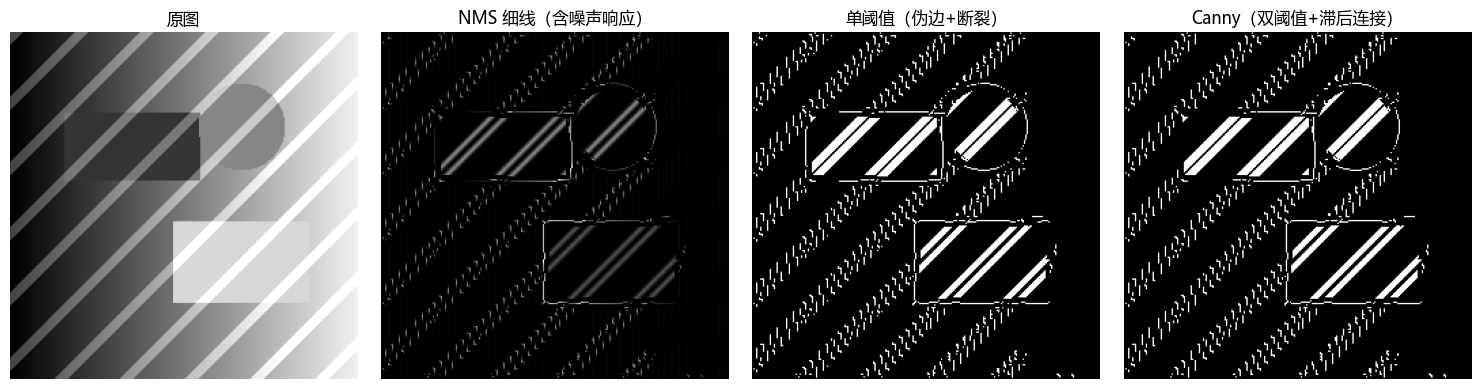

被滞后连接补回来的边像素数: 0


In [3]:
# ---------- 实验 3：Canny 完整手写（高斯→Sobel→NMS→双阈值→滞后连接） ----------
def gauss_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1, dtype=float)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return k / k.sum()

def canny(g, sigma=1.2, low=0.05, high=0.18, ksize=5):
    blur = conv2d(g, gauss_kernel(ksize, sigma))
    _, _, mag, ang = sobel_grad(blur)
    mag_n = mag / (mag.max() + 1e-12)
    n = nms(mag_n, ang)
    H, W = g.shape
    strong = (n > high).astype(np.int8)
    weak = ((n >= low) & (n <= high)).astype(np.int8)
    changed = True
    while changed:                                    # 滞后连接：弱边邻接强边 -> 升级
        changed = False
        for i in range(1, H - 1):
            for j in range(1, W - 1):
                if weak[i, j] and not strong[i, j] and strong[i - 1:i + 2, j - 1:j + 2].any():
                    strong[i, j] = 1
                    changed = True
    return strong.astype(float), n

edges, n = canny(img)
simple = (n > 0.05).astype(float)                     # 对照组：单阈值（无滞后连接）
print('Canny 边像素占比: %.2f%% vs 单阈值: %.2f%%' % (100 * edges.mean(), 100 * simple.mean()))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(n, cmap='gray'); axes[1].set_title('NMS 细线（含噪声响应）'); axes[1].axis('off')
axes[2].imshow(simple, cmap='gray'); axes[2].set_title('单阈值（伪边+断裂）'); axes[2].axis('off')
axes[3].imshow(edges, cmap='gray'); axes[3].set_title('Canny（双阈值+滞后连接）'); axes[3].axis('off')
plt.tight_layout(); plt.savefig('images/cv01_canny.png', dpi=110, bbox_inches='tight'); plt.show()

# 验证滞后连接确实补上了断裂：单阈值中属于"弱边"但被保留的像素数
weak_saved = ((simple == 0) & (edges == 1)).sum()
print('被滞后连接补回来的边像素数:', int(weak_saved))


## 5. Harris 角点：结构张量与响应 R

角点 = 两个方向的边同时剧烈变化。Harris 用**结构张量（二阶矩）**描述局部梯度分布：

$$M = \\begin{bmatrix} \\sum I_x^2 & \\sum I_x I_y \\\\ \\sum I_x I_y & \\sum I_y^2 \\end{bmatrix}, \\qquad R = \\det(M) - k\\,\\text{trace}(M)^2$$

- 平坦区：$M$ 特征值都小 → $R$ 负
- 边缘：一个特征值大 → $R$ 接近 0
- **角点：两个特征值都大 → $R$ 正且大**

> 面试点：$M$ 的两个特征值 $\\lambda_1,\\lambda_2$ 才是本质判据；$R$ 是便宜近似。
> $k$ 经验值 0.04–0.06。还有 Shi-Tomasi 变体：$R=\\min(\\lambda_1,\\lambda_2)$。


检测到角点数: 32 （合成图里方块/圆角共有 12 个真角点级别的响应）


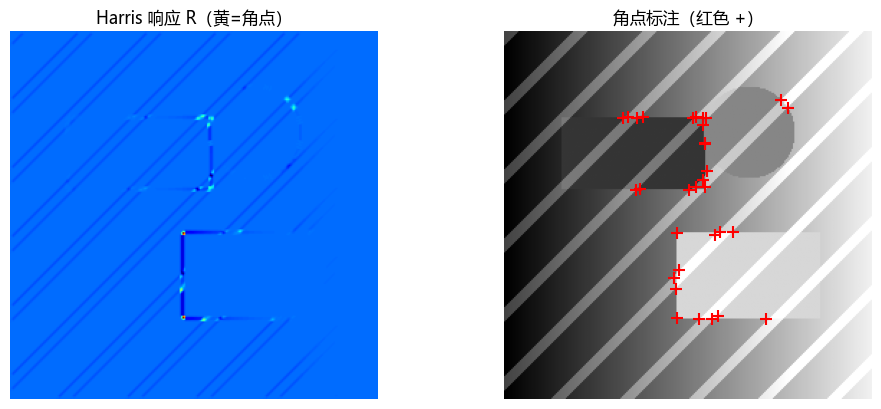

In [4]:
# ---------- 实验 4：手写 Harris 角点检测 ----------
def harris_response(g, win=3, k=0.04):
    Ix = conv2d(g, SOBEL_X); Iy = conv2d(g, SOBEL_Y)
    Sxx = conv2d(Ix * Ix, np.ones((win, win)) / win ** 2)
    Syy = conv2d(Iy * Iy, np.ones((win, win)) / win ** 2)
    Sxy = conv2d(Ix * Iy, np.ones((win, win)) / win ** 2)
    det = Sxx * Syy - Sxy ** 2
    trace = Sxx + Syy
    return det - k * trace ** 2

R = harris_response(img)
# 阈值 + 3x3 局部极大（非极大值抑制在 R 上再做一遍）
th = 0.01 * R.max()
local_max = np.zeros_like(R, dtype=bool)
for i in range(1, R.shape[0] - 1):
    for j in range(1, R.shape[1] - 1):
        local_max[i, j] = R[i, j] >= R[i - 1:i + 2, j - 1:j + 2].max() - 1e-12
corners = np.argwhere((R > th) & local_max)
print('检测到角点数:', len(corners), '（合成图里方块/圆角共有 12 个真角点级别的响应）')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].imshow(R, cmap='jet'); axes[0].set_title('Harris 响应 R（黄=角点）'); axes[0].axis('off')
axes[1].imshow(img, cmap='gray')
for (i, j) in corners:
    axes[1].plot(j, i, 'r+', ms=8, mew=1.5)
axes[1].set_title('角点标注（红色 +）'); axes[1].axis('off')
plt.tight_layout(); plt.savefig('images/cv01_harris.png', dpi=110, bbox_inches='tight'); plt.show()


## 6. HOG 特征：方向直方图 + Block 归一化

HOG（Histogram of Oriented Gradients）是深度学习前行人检测（DPM 等）的主力特征，思路：

1. 算梯度幅值/方向（同上）
2. 分成 **cell**（如 8×8），把梯度按方向投进 **9-bin** 直方图（180° 分 9 桶，每桶 20°）
3. 相邻 2×2 cell 组成 **block**，做 L2 归一化 + 截断（clip 0.2）→ 抗光照变化
4. 特征维度 = cell 数 × block 内 cell 数 × bin 数

**为什么 block 归一化有效**：光照/对比度变化会整体缩放梯度幅值，
归一化后幅值尺度被拉回，只剩「方向分布」这种光照不变的信息。


HOG 特征维度: 34596 （256x256 -> 32x32 cell -> 31x31 block -> 31*31*36）
同类 HOG 距离均值: 2.529 | 异类 HOG 距离均值: 4.032 -> 可分性良好


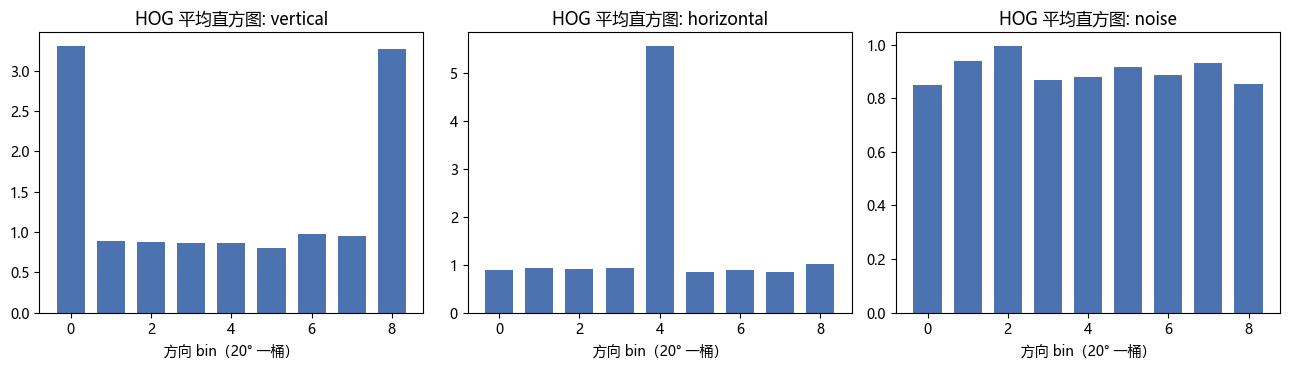

竖边图：bin 0/8（水平方向梯度=竖边）能量高；横边图：bin 4（垂直方向梯度）能量高；噪声：均匀


In [5]:
# ---------- 实验 5：手写 HOG + 正负样本判别力实验 ----------
def hog_feature(g, cell=8, block=2, bins=9):
    Gx, Gy, mag, ang = sobel_grad(g)
    ang_bin = (ang / (180 / bins)).astype(int) % bins
    H, W = g.shape
    nc, nr = H // cell, W // cell
    ch = np.zeros((nc, nr, bins))
    for i in range(H):
        for j in range(W):
            ch[i // cell, j // cell, ang_bin[i, j]] += mag[i, j]
    feats = []
    for bi in range(nc - block + 1):
        for bj in range(nr - block + 1):
            blk = ch[bi:bi + block, bj:bj + block].ravel()
            nrm = np.sqrt(blk @ blk + 1e-6)
            feats.append(np.clip(blk / nrm, 0, 0.2))       # L2 归一化 + 截断 0.2
    return np.concatenate(feats), ch

feat, cell_hists = hog_feature(img)
print('HOG 特征维度:', feat.size, '（256x256 -> 32x32 cell -> 31x31 block -> 31*31*36）')

# 判别力实验：竖边图 vs 横边图 vs 纯噪声，同类近、异类远
def syn_patch(kind, size=64):
    base = rng.random((size, size)) * 0.1 + 0.45
    if kind == 'vertical':
        base[:, :size // 2] -= 0.3; base[:, size // 2:] += 0.3
    elif kind == 'horizontal':
        base[:size // 2, :] -= 0.3; base[size // 2:, :] += 0.3
    return np.clip(base, 0, 1)

import itertools
kind2lab = {'vertical': 0, 'horizontal': 1, 'noise': 2}
feats = []
for kind in kind2lab:
    for _ in range(3):
        feats.append((kind, hog_feature(syn_patch(kind))[0]))
def L2(a, b): return float(np.linalg.norm(a - b))
same, diff = [], []
for (ka, fa), (kb, fb) in itertools.combinations(feats, 2):
    (same if ka == kb else diff).append(L2(fa, fb))
print('同类 HOG 距离均值: %.3f | 异类 HOG 距离均值: %.3f -> 可分性良好' %
      (np.mean(same), np.mean(diff)))
assert np.mean(same) < np.mean(diff)

# cell 直方图可视化
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, kind in zip(axes, ['vertical', 'horizontal', 'noise']):
    p = syn_patch(kind)
    _, ch = hog_feature(p, cell=8)
    mean_cell = ch.mean(axis=(0, 1))                    # 平均方向直方图
    ax.bar(np.arange(9), mean_cell, width=0.7, color='#4C72B0')
    ax.set_title('HOG 平均直方图: %s' % kind)
    ax.set_xlabel('方向 bin（20° 一桶）')
plt.tight_layout(); plt.savefig('images/cv01_hog.png', dpi=110, bbox_inches='tight'); plt.show()
print('竖边图：bin 0/8（水平方向梯度=竖边）能量高；横边图：bin 4（垂直方向梯度）能量高；噪声：均匀')


## 7. 特征描述子与匹配：从 HOG 到 SIFT

| 描述子 | 思路 | 不变性 |
|--------|------|--------|
| 块灰度（NCC） | 滑窗算归一化互相关 | 平移（光照线性） |
| HOG | cell 方向直方图 + block 归一化 | 光照、局部几何 |
| **SIFT** | 尺度空间 DoG 找关键点 + 128 维方向直方图 | **尺度 + 旋转 + 光照** |
| SURF | 盒滤波近似 Hessian 加速 SIFT | 同 SIFT 更快 |
| ORB | FAST 角点 + BRIEF 二进制描述 | 快（移动端） |

**匹配度量**：归一化互相关（NCC）、欧氏距离比测试（最近/次近 < 0.8 才接受，Lowe 提的 ratio test）。

> 面试常问「为什么 SIFT 对旋转/尺度不变」：关键点带**主方向**（直方图峰值）与**尺度**（DoG 极值），
> 描述子先旋转到主方向、按尺度采样 → 描述本身与旋转/缩放解耦。


NCC 最高位置 (y,x) = (np.int64(48), np.int64(48))  得分 = 1.0000  | 模板真实位置 (y,x) = (48, 48)


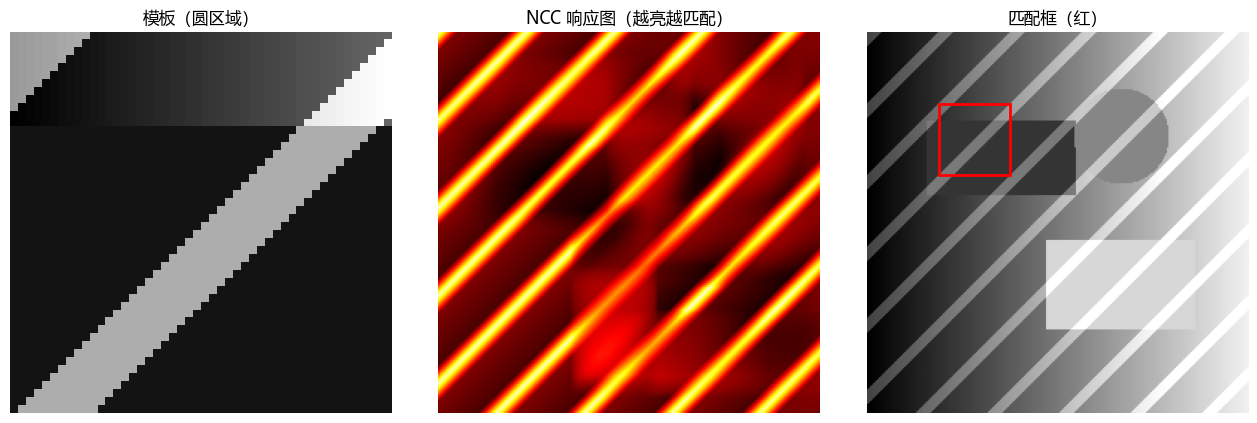

结论：滑窗 + 相似度度量 = 最朴素的"特征匹配"；SIFT 就是给它加上尺度/旋转不变的描述子


In [6]:
# ---------- 实验 6：模板匹配（归一化互相关 NCC） ----------
def ncc_score(a, b):
    a0 = a - a.mean(); b0 = b - b.mean()
    denom = np.linalg.norm(a0) * np.linalg.norm(b0) + 1e-9
    return float((a0 * b0).sum() / denom)

# 模板 = 图中的圆区域；在整图滑窗找它
H, W = img.shape
ts, te = 48, 96                                        # 模板范围（圆）
templ = img[ts:te, ts:te]
scores = np.zeros((H - templ.shape[0] + 1, W - templ.shape[1] + 1))
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        scores[i, j] = ncc_score(img[i:i + templ.shape[0], j:j + templ.shape[1]], templ)
bi, bj = np.unravel_index(np.argmax(scores), scores.shape)
print('NCC 最高位置 (y,x) =', (bi, bj), ' 得分 = %.4f' % scores[bi, bj],
      ' | 模板真实位置 (y,x) =', (ts, ts))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(templ, cmap='gray'); axes[0].set_title('模板（圆区域）'); axes[0].axis('off')
axes[1].imshow(scores, cmap='hot'); axes[1].set_title('NCC 响应图（越亮越匹配）'); axes[1].axis('off')
axes[2].imshow(img, cmap='gray')
rect = plt.Rectangle((bj, bi), templ.shape[1], templ.shape[0], fill=False, edgecolor='r', lw=2)
axes[2].add_patch(rect); axes[2].set_title('匹配框（红）'); axes[2].axis('off')
plt.tight_layout(); plt.savefig('images/cv01_match.png', dpi=110, bbox_inches='tight'); plt.show()
print('结论：滑窗 + 相似度度量 = 最朴素的"特征匹配"；SIFT 就是给它加上尺度/旋转不变的描述子')


## 8. 边缘检测脉络谱系（面试一张图）

```
灰度 → 梯度(Sobel/Prewitt/Scharr) → NMS 细线化
                                    ├── 单阈值（脆、断）
                                    └── Canny（双阈值+滞后连接）→ 经典最优
角点 → Harris R 响应 → 阈值+局部极大
特征 → HOG(cell+block 归一化) → SIFT(尺度空间+主方向) → ORB(二进制, 快)
```

**Canny 为什么是"标准答案"**：去噪(高斯) + 细线化(NMS) + 伪边抑制(双阈值) + 断裂补全(滞后)，
四件事各司其职，每一件都能单独被追问。


## 9. 数字敏感度与易错点

- Sobel 核中心权重 2；Scharr 用 3/10
- 梯度方向折叠到 $[0,180°)$（不区分边方向 180° 翻转）
- HOG 默认：cell 8×8、block 2×2、9 bin、180°、L2-Hys（clip 0.2）
- SIFT 描述子 **128 维**（4×4 空间 × 8 方向）
- Canny 阈值经验：$T_{high}:T_{low} = 2{:}1 \sim 3{:}1$
- Harris $k=0.04$；Shi-Tomasi 用 $\min(\\lambda_1,\\lambda_2)$

**易错点**
1. 先模糊再求梯度（直接对噪声图求导会把噪声当边）
2. NMS 方向分箱边界（45° 分箱要按梯度方向而非边方向）
3. 归一化幅值后再设阈值（幅值范围随图像不同，归一化让阈值可移植）
4. 滞后连接用 8 邻域；用 4 邻域会漏对角弱边


## 10. 面试速答（30 秒背诵版）

- **Sobel vs Prewitt**：Sobel 中间行权重 2 → 抗噪更好；本质=平滑+差分
- **Canny 五步**：高斯→Sobel→NMS→双阈值→滞后连接；为什么滞后连接（连续性先验补断裂）
- **Harris 为什么能检角点**：结构张量 M 两特征值都大；R = det − k·trace²
- **HOG 怎么抗光照**：block 内 L2 归一化把幅值尺度拉回，只剩方向分布
- **SIFT 怎么做到旋转/尺度不变**：主方向对齐 + 尺度空间采样
- **特征匹配**：NCC / 欧氏距离 + ratio test（最近:次近 < 0.8）


## 11. 自测清单

- [ ] 手写 Sobel（Gx/Gy 核），说清为什么中心权重是 2（平滑+差分）
- [ ] 手写 NMS（4 方向分箱 + 沿梯度方向比较），说清它把宽边变细线
- [ ] 手写 Canny 五步全流程（含滞后连接 BFS），说清双阈值为什么比单阈值好
- [ ] 手写 Harris 响应 R（结构张量 + det/trace），说清三个区域的 R 符号
- [ ] 手写 HOG（cell 直方图 + block L2 归一化 + 截断），能口算维度
- [ ] 口算：128×128 图、cell=8、block=2、9bin 的 HOG 维度（16→15，15×15×36=8100）
- [ ] 说清 SIFT 的尺度空间/主方向如何带来不变性
- [ ] 说清模板匹配 NCC 公式与分母加 1e-9 的原因（防除零）

> 💡 本篇验收指路：`09-计算机视觉/README.md`「边缘/角点/特征」打勾；
> 下一篇 `02-卷积神经网络深入` 把这些滤波器的思想搬到可学习的卷积核上。
